This makes a visualization of selecting a subsample of the network.

In [14]:
import matplotlib.pyplot as plt
from importlib import reload
import networkx as nx
import random
import numpy as np

import metaCommunityMx
import community_sim
import metrics_and_plotting
reload(metaCommunityMx)
reload(metrics_and_plotting)
reload(community_sim)

<module 'community_sim' from '/Users/fionacallahan/Documents/Nielsen_lab/TheoryCoOccur/community_sim.py'>

In [15]:
# for random matrix
alpha = 0.001
interactStren = (1/5) * alpha
nSpec = 100
pPositive = 0.5

# for modular matrix or hub mx
nModules = 5
pWithinMod = 0.9

samplesize = int(0.5 * nSpec) # number of species to sample

In [16]:
modMx = metaCommunityMx.generateModularMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = nSpec, pWithinMod = pWithinMod, pBetweenMod = 0, nModules = nModules)
modSize = nSpec // nModules
myModules = [range(i * modSize, (i+1) * modSize) for i in range(nModules)]
step = 200
modMx = metrics_and_plotting.rewire_modular(matrix = modMx, modules = myModules, nEdges = step, interactStren = interactStren)
b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))

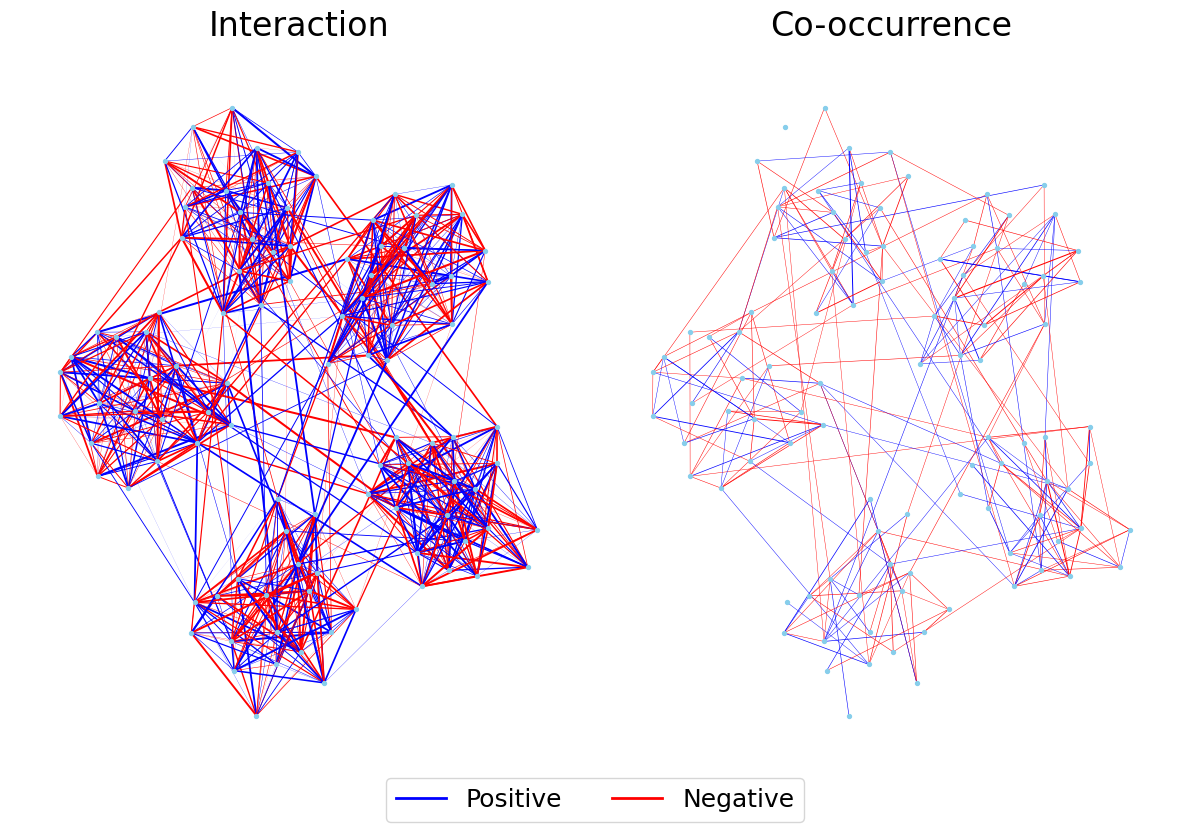

In [17]:
# visualize
sim_res = community_sim.simulate_coOccurrence(samplesize = 50, numtrials = 500, a = modMx, b = b, alpha = alpha, tmax = 100, y0 = None)
coAbd = np.round(sim_res[0], 0)

# Diagnostic: check for zero variance and identical vectors -- note this sometimes happens when there are too many negative interactions
# if this happens, we will have some NaN values in the correlation matrix.
variances = np.var(coAbd, axis=0)
zero_var_count = np.sum(variances == 0)
if zero_var_count > 0:
        print(f"WARNING: {zero_var_count} species have zero variance in run_cooccurrence.get_coocc_network()")

# Check for identical columns (species with identical abundance patterns)
nSpec = len(modMx[1,])
identical_count = 0
for i in range(nSpec):
        for j in range(i+1, nSpec):
                if np.array_equal(coAbd[:, i], coAbd[:, j]):
                        identical_count += 1
if identical_count > 0:
        print(f"WARNING: {identical_count} pairs of species have identical abundance vectors in run_cooccurrence.get_coocc_network()")

pearson_corr = np.corrcoef(coAbd, rowvar = False)
network_coocc = np.greater(pearson_corr, 0.13).astype(int) - np.less(pearson_corr, -0.13).astype(int)
np.fill_diagonal(network_coocc, 0)
G_coocc = nx.from_numpy_array(network_coocc)

G_inter = nx.from_numpy_array(modMx != 0)
pos = nx.spring_layout(G_inter, seed=42)

G_inter = nx.from_numpy_array(modMx != 0)

normalized_interMx = modMx / (modMx.max() - modMx.min())
normalized_pearson_corr = pearson_corr / (pearson_corr.max() - pearson_corr.min())

import pickle, os
os.makedirs('figure_data', exist_ok=True)
with open('figure_data/vn_networks.pkl', 'wb') as f:
    pickle.dump({
        'modMx': modMx,
        'network_coocc': network_coocc,
        'pearson_corr': pearson_corr,
        'pos': pos,
        'normalized_interMx': normalized_interMx,
        'normalized_pearson_corr': normalized_pearson_corr,
    }, f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

# Plot interaction network
nx.draw(G_inter, pos, ax=ax1, with_labels=False, node_color='skyblue',
        node_size=8, edge_color=['red' if normalized_interMx[u,v] < 0 else 'blue' for u,v in G_inter.edges()],
        width=[abs(normalized_interMx[u,v]) * 3 for u,v in G_inter.edges()])
ax1.set_title("Interaction", fontsize=24)

# Plot co-occurrence network
nx.draw(G_coocc, pos, ax=ax2, with_labels=False, node_color='skyblue',
        node_size=8, edge_color=['red' if normalized_pearson_corr[u,v] < 0 else 'blue' for u,v in G_coocc.edges()],
        width=[abs(normalized_pearson_corr[u,v]) * 3 for u,v in G_coocc.edges()])
ax2.set_title("Co-occurrence", fontsize=24)

# Add color legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='blue', linewidth=2, label='Positive'),
                   Line2D([0], [0], color='red', linewidth=2, label='Negative')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=18, frameon=True, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

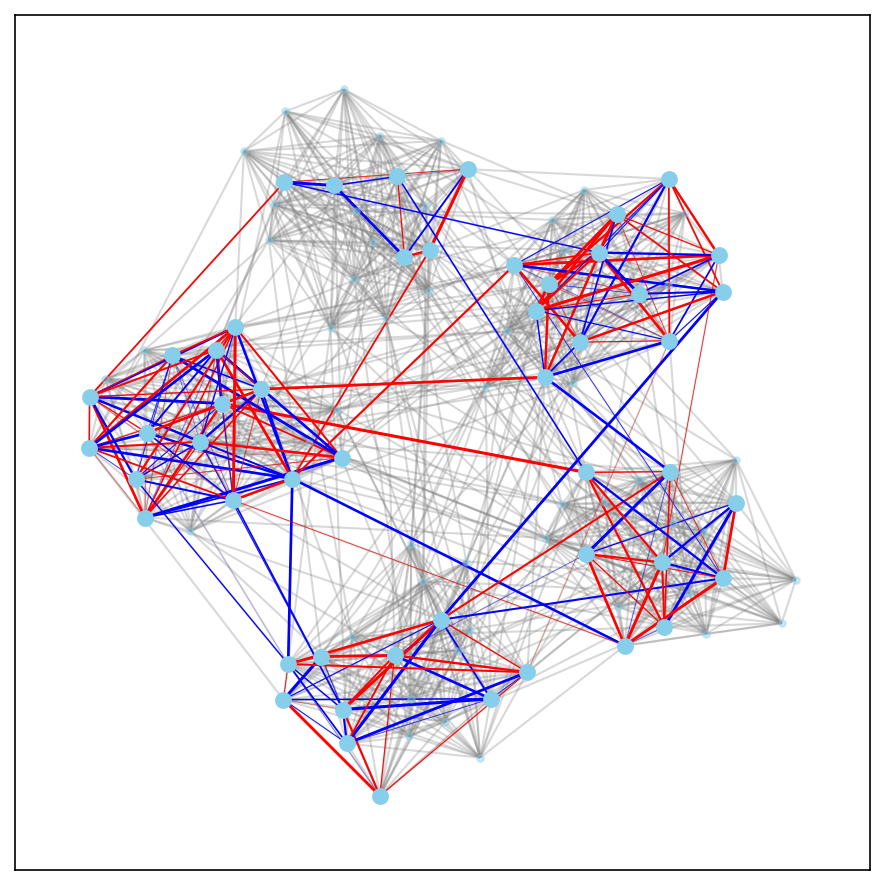

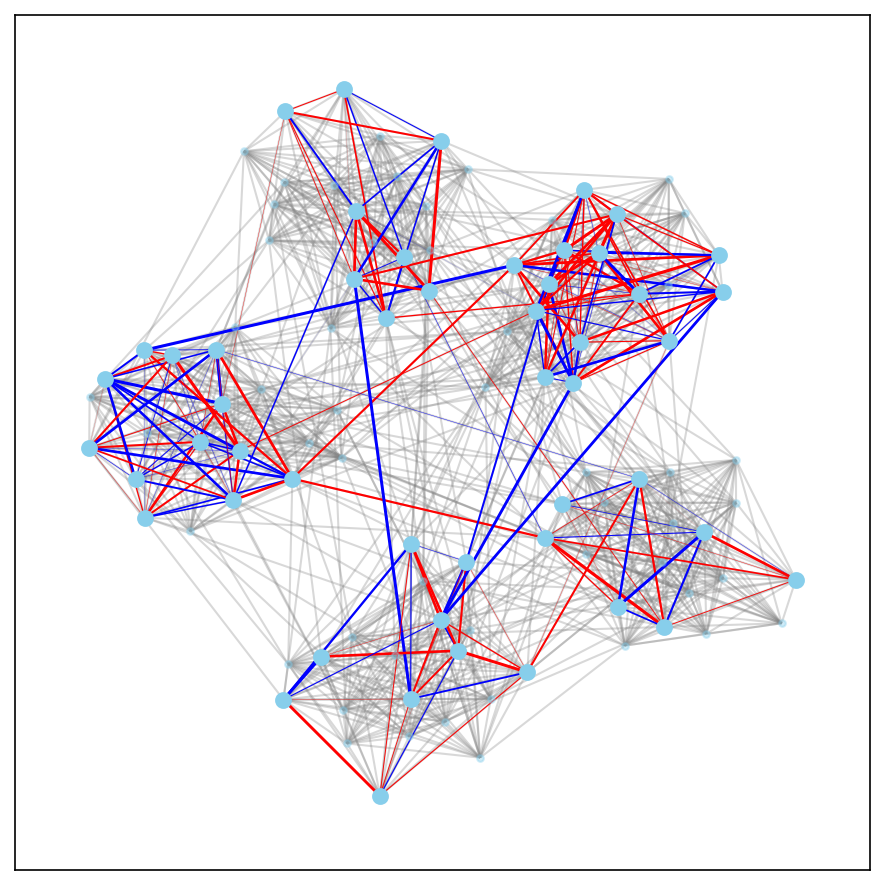

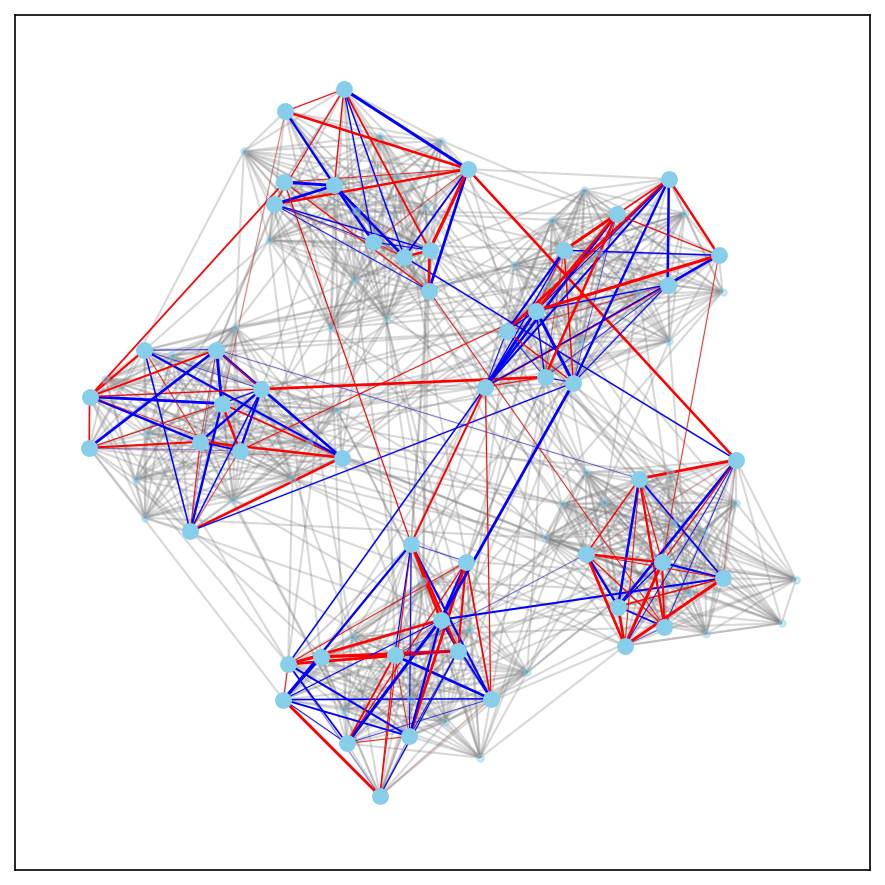

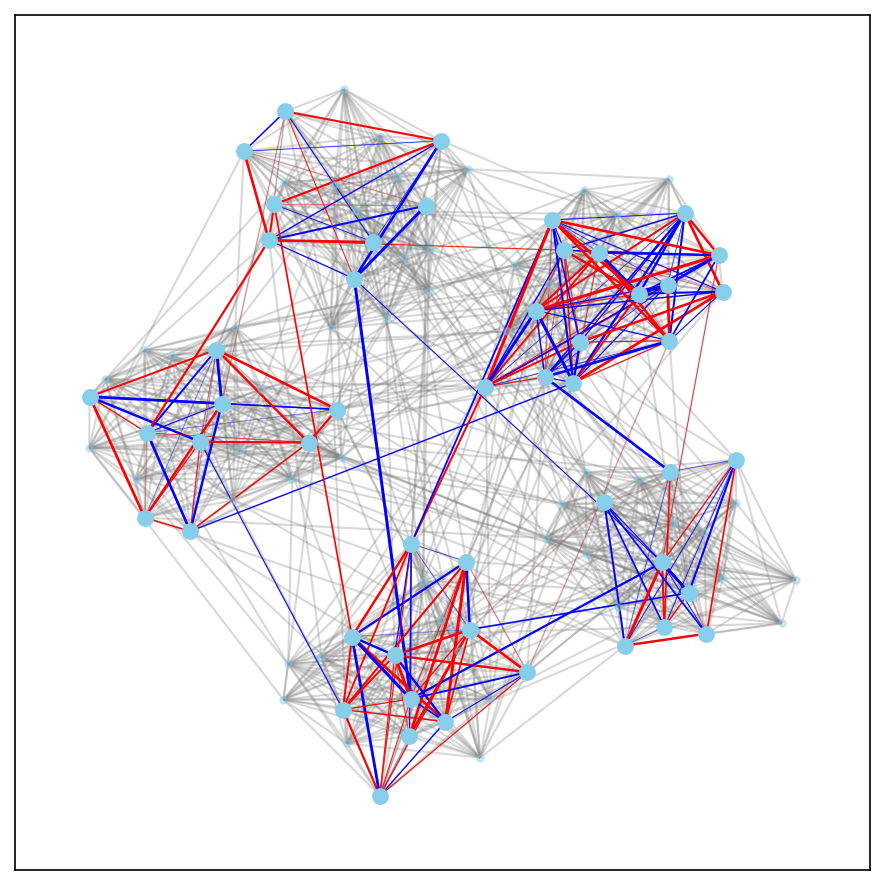

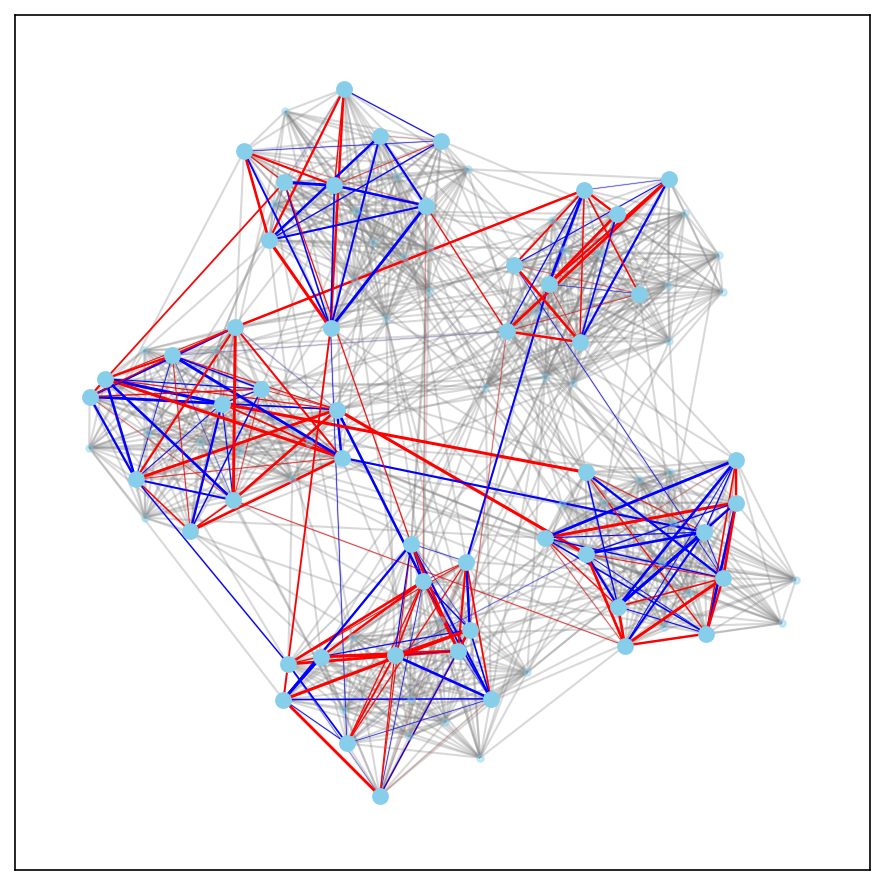

In [18]:
import pickle, os
os.makedirs('figure_data', exist_ok=True)
with open('figure_data/vn_subsampled.pkl', 'wb') as f:
    pickle.dump({
        'G_inter_adj': nx.to_numpy_array(G_inter),
        'pos': pos,
        'normalized_interMx': normalized_interMx,
    }, f)

# Sample nodes and highlight - 5 different samples from the same interaction network
for i in range(5):
    fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
    
    sample_nodes = random.sample(list(G_inter.nodes()), k=50)
    sampled_inter_edges = [(u,v) for u,v in G_inter.edges() if u in sample_nodes and v in sample_nodes]
    
    # Draw all nodes/edges faded first
    nx.draw_networkx_nodes(G_inter, pos, ax=ax, node_color='skyblue', node_size=10, alpha=0.4)
    nx.draw_networkx_edges(G_inter, pos, ax=ax, alpha=0.3, width=1, edge_color='gray')
    # Draw sampled nodes/edges highlighted
    nx.draw_networkx_nodes(G_inter, pos, ax=ax, nodelist=sample_nodes, node_color='skyblue', node_size=50)
    nx.draw_networkx_edges(G_inter, pos, ax=ax, edgelist=sampled_inter_edges,
            edge_color=['red' if normalized_interMx[u,v] < 0 else 'blue' for u,v in sampled_inter_edges],
            width=[abs(normalized_interMx[u,v]) * 3 for u,v in sampled_inter_edges])
    plt.tight_layout()
    plt.show()